<a href="https://colab.research.google.com/github/sagarali110/quiz2/blob/main/Hand_Written_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import tensorflow as tf
import numpy as np
import os

# Load dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# Ensure a local directory exists before saving the model
os.makedirs("./model/", exist_ok=True)

# Save model locally
model.save("./model/hcr_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9524 - loss: 0.1556 - val_accuracy: 0.9802 - val_loss: 0.0615
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9836 - loss: 0.0538 - val_accuracy: 0.9880 - val_loss: 0.0348
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9880 - loss: 0.0392 - val_accuracy: 0.9917 - val_loss: 0.0271
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9900 - loss: 0.0316 - val_accuracy: 0.9884 - val_loss: 0.0352
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9909 - val_loss: 0.0304


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



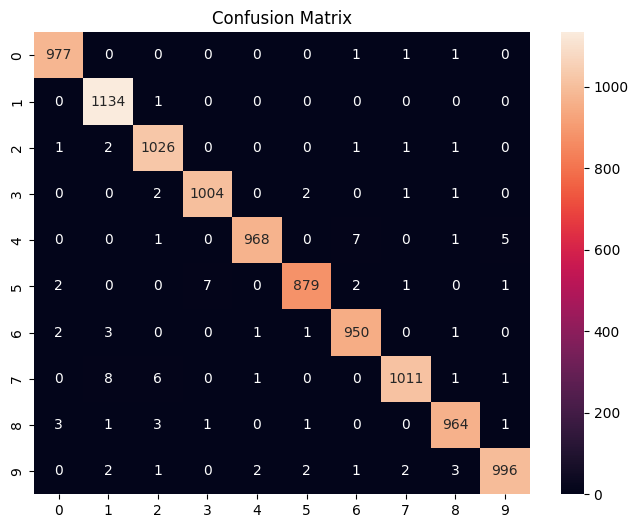

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install streamlit -q
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image

# Load model
model = tf.keras.models.load_model("model/hcr_model.keras")

st.title("🧠 Handwritten Character Recognition")
st.write("Upload a handwritten digit image (28x28 or clear black-white digit)")

file = st.file_uploader("Upload Image", type=["png", "jpg", "jpeg"])

if file:
    img = Image.open(file).convert('L')
    img = img.resize((28,28))

    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1,28,28,1)

    prediction = model.predict(img_array)
    result = np.argmax(prediction)

    st.image(img, caption="Input Image")
    st.write(f"### Predicted Digit: {result}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.3 MB/s eta 0:00:00


2026-04-26 11:07:02.487 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.157 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-26 11:07:03.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.168 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:07:03.169 Thread 'MainThread': mi

In [ ]:
# These are the libraries used in this project:
# tensorflow
# numpy
# matplotlib
# seaborn
# scikit-learn
# streamlit
# pillow

print("Libraries listed. Use !pip install <name> if any are missing.")

Libraries listed. Use !pip install <name> if any are missing.


In [ ]:
model.save("hcr_model.keras")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



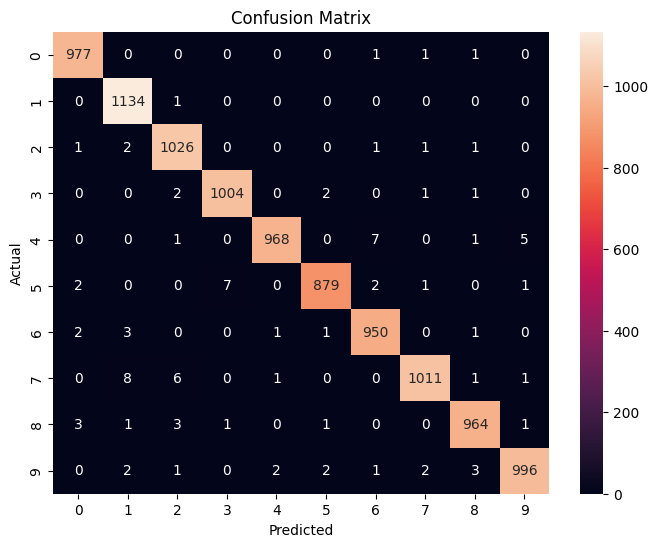

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image

model = tf.keras.models.load_model("hcr_model.keras")

st.title("Handwritten Digit Recognizer")

file = st.file_uploader("Upload Image", type=["png","jpg","jpeg"])

if file:
    img = Image.open(file).convert('L')
    img = img.resize((28,28))

    img_array = np.array(img)/255.0
    img_array = img_array.reshape(1,28,28,1)

    pred = model.predict(img_array)
    result = np.argmax(pred)

    st.image(img)
    st.write(f"Prediction: {result}")

2026-04-26 11:10:44.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.525 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.531 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.539 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:10:44.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!streamlit run streamlit_app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: streamlit_app.py


In [ ]:

from tensorflow.keras.datasets import mnist
import tensorflow_datasets as tfds

# Load EMNIST Letters
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.I9KK8L_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.I9KK8L_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:

import tensorflow as tf

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0

    # Fix rotation issue
    image = tf.transpose(image)
    image = tf.image.flip_left_right(image)

    image = tf.expand_dims(image, -1)

    return image, label - 1  # labels 1–26 → 0–25

ds_train = ds_train.map(preprocess).batch(128)
ds_test = ds_test.map(preprocess).batch(128)

In [ ]:
tf.keras.layers.Dense(26, activation='softmax')

<Dense name=dense_4, built=False>

In [ ]:
pip install streamlit-drawable-canvas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00


In [ ]:

import streamlit as st
import numpy as np
import tensorflow as tf
from streamlit_drawable_canvas import st_canvas
from PIL import Image

model = tf.keras.models.load_model("model/hcr_model.keras")

st.title("🧠 Handwritten Character Recognition (A–Z)")

canvas = st_canvas(
    fill_color="black",
    stroke_width=10,
    stroke_color="white",
    background_color="black",
    height=280,
    width=280,
    drawing_mode="freedraw",
    key="canvas",
)

if canvas.image_data is not None:
    img = canvas.image_data.astype("uint8")

    img = Image.fromarray(img).convert('L')
    img = img.resize((28,28))

    img_array = np.array(img)/255.0
    img_array = img_array.reshape(1,28,28,1)

    pred = model.predict(img_array)
    result = np.argmax(pred)

    st.write(f"### Predicted Character: {chr(result + 65)}")

2026-04-26 11:27:03.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.329 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 11:27:03.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar